**U.S. County-Level Drought Hotspot Analysis**

**Date:** May 26, 2026  
**Data:** U.S. Drought Monitor (05/26/2026) + U.S. Census TIGER/Line Counties

**Overview**

This project identifies county-level drought hotspots across the contiguous United States 
using U.S. Drought Monitor data. Spatial autocorrelation methods (Moran's I and LISA) 
are used to determine whether drought severity forms significant spatial clusters.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot

In [2]:
# Load national county boundaries
counties = gpd.read_file("tl_2025_us_county.shp")

# Load U.S. Drought Monitor data (May 26, 2026)
drought = gpd.read_file("USDM_20260526.shp")

print("Counties shape:", counties.shape)
print("Drought shape:", drought.shape)
print("Counties CRS:", counties.crs)
print("Drought CRS:", drought.crs)

Counties shape: (3235, 19)
Drought shape: (5, 5)
Counties CRS: epsg:4269
Drought CRS: epsg:4326


In [3]:
# Exclude Alaska (02), Hawaii (15), and US territories
# to keep the analysis focused on the contiguous US
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties_conus = counties[~counties["STATEFP"].isin(exclude)].copy()

print("CONUS counties:", counties_conus.shape[0])

# Match CRS
drought = drought.to_crs(counties_conus.crs)
print("CRS matched:", counties_conus.crs)

CONUS counties: 3109
CRS matched: epsg:4269


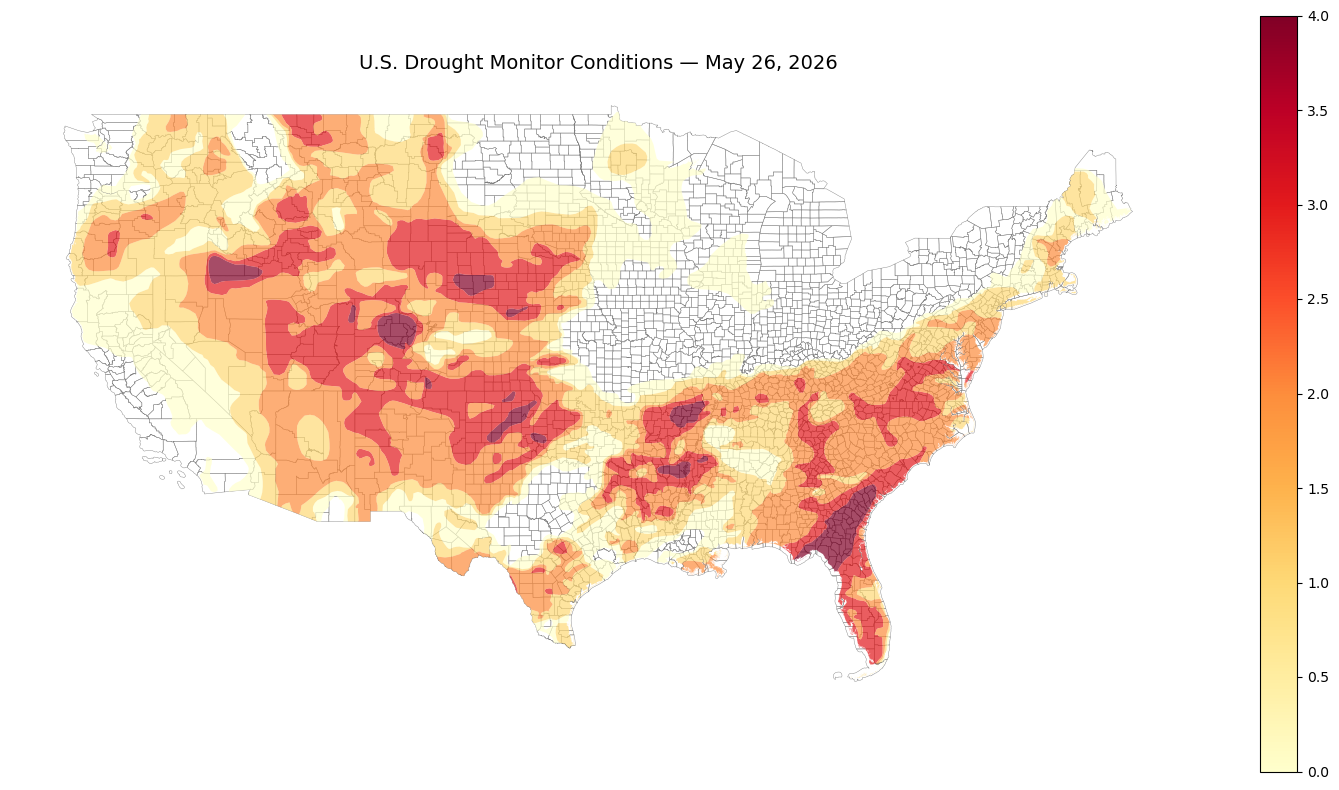

In [4]:
drought_conus = gpd.clip(drought, counties_conus)

# Quick look at drought coverage
fig, ax = plt.subplots(figsize=(15, 8))
counties_conus.plot(ax=ax, edgecolor="gray", facecolor="none", linewidth=0.3)
drought_conus.plot(ax=ax, column="DM", legend=True, alpha=0.7, cmap="YlOrRd")
plt.title("U.S. Drought Monitor Conditions — May 26, 2026", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
# Project to equal-area CRS for accurate area calculations
counties_proj = counties_conus.to_crs(epsg=5070)
drought_proj = drought_conus.to_crs(epsg=5070)

# Calculate total area of each county
counties_proj["county_area"] = counties_proj.geometry.area

# Overlay drought polygons with county boundaries
county_drought = gpd.overlay(counties_proj, drought_proj, how="intersection")
county_drought["intersect_area"] = county_drought.geometry.area
county_drought["weighted_dm"] = county_drought["DM"] * county_drought["intersect_area"]

# Aggregate to county level
county_summary = county_drought.groupby("GEOID").agg(
    drought_area=("intersect_area", "sum"),
    weighted_dm_sum=("weighted_dm", "sum")
).reset_index()

print("Counties with drought overlap:", county_summary.shape[0])
county_summary.head()

Counties with drought overlap: 2422


,GEOID,drought_area,weighted_dm_sum
0,01001,1.565309e+09,2.210183e+09
1,01003,4.266381e+09,5.757254e+09
2,01005,2.342684e+09,4.685367e+09
3,01007,1.621761e+09,1.560976e+09
4,01009,1.685119e+09,0.000000e+00


In [6]:
# Join summary back to county layer
counties_proj = counties_proj.merge(county_summary, on="GEOID", how="left")

# Fill counties with no drought with 0
counties_proj[["drought_area", "weighted_dm_sum"]] = \
    counties_proj[["drought_area", "weighted_dm_sum"]].fillna(0)

# Calculate area-weighted average drought severity
counties_proj["avg_drought_severity"] = (counties_proj["weighted_dm_sum"] / counties_proj["county_area"])

# Percentage of county area affected by drought
counties_proj["percent_drought_area"] = (counties_proj["drought_area"] / counties_proj["county_area"]) * 100

counties_proj[["NAME", "STATEFP", "avg_drought_severity", 
               "percent_drought_area"]].sort_values("avg_drought_severity", ascending=False).head(10)

,NAME,STATEFP,avg_drought_severity,percent_drought_area
1270,Brantley,13,4.0,100.0
90,Madison,12,4.0,100.0
860,Atkinson,13,4.0,100.0
381,Suwannee,12,4.0,100.0
1572,Evans,13,4.0,100.0
10,Effingham,13,4.0,100.0
1056,Coffee,13,4.0,100.0
1057,Ware,13,4.0,100.0
943,Lafayette,12,4.0,100.0
1712,Charlton,13,4.0,100.0


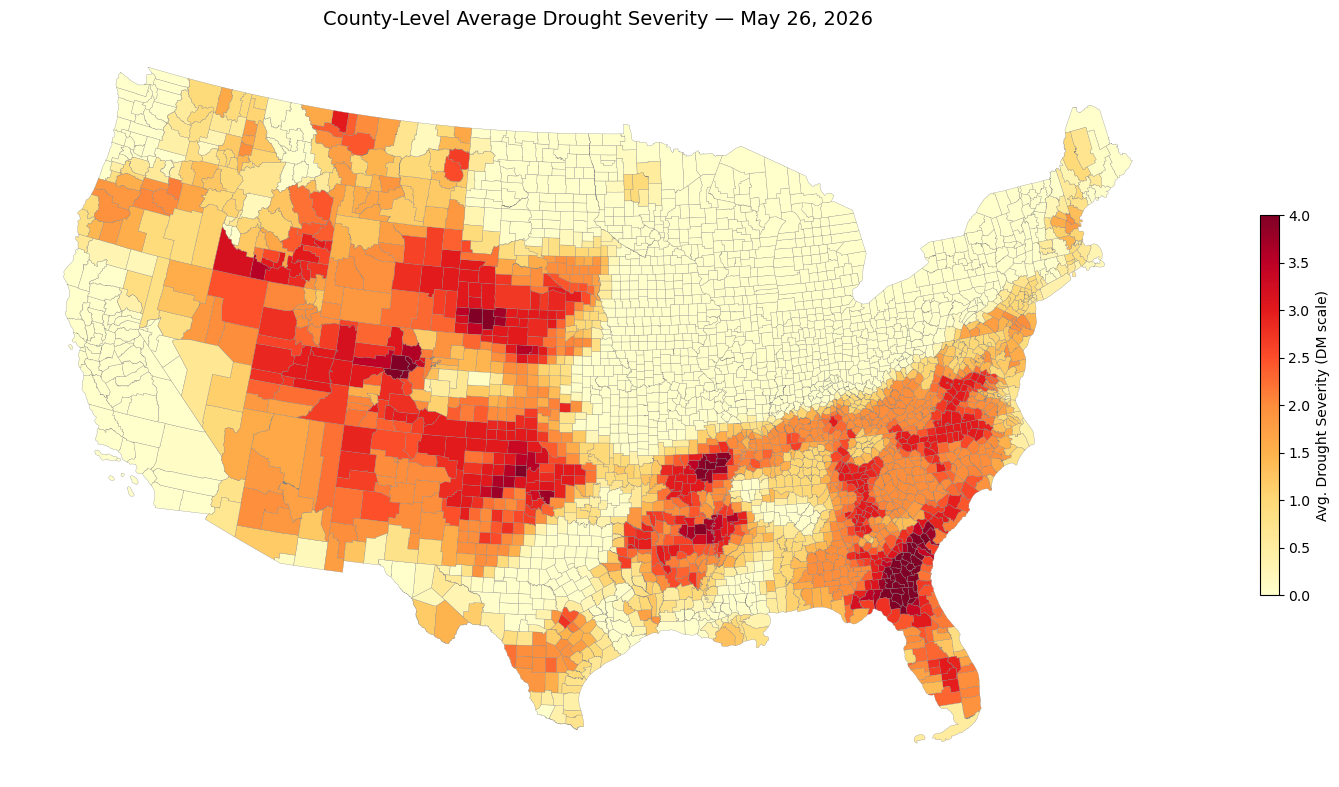

In [7]:
fig, ax = plt.subplots(figsize=(15, 8))
counties_proj.plot(
    column="avg_drought_severity",
    cmap="YlOrRd",
    edgecolor="gray",
    linewidth=0.2,
    legend=True,
    legend_kwds={"label": "Avg. Drought Severity (DM scale)", 
                 "shrink": 0.5},
    ax=ax
)
plt.title("County-Level Average Drought Severity — May 26, 2026", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig("us_county_drought_severity.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Build spatial weights (Queen contiguity)
w = Queen.from_dataframe(counties_proj)
w.transform = "r"

y = counties_proj["avg_drought_severity"]

# Compute Moran's I
moran = Moran(y, w)
print(f"Moran's I:  {moran.I:.4f}")
print(f"p-value:    {moran.p_sim}")
print(f"z-score:    {moran.z_sim:.4f}")

Moran's I:  0.9123
p-value:    0.001
z-score:    88.6359


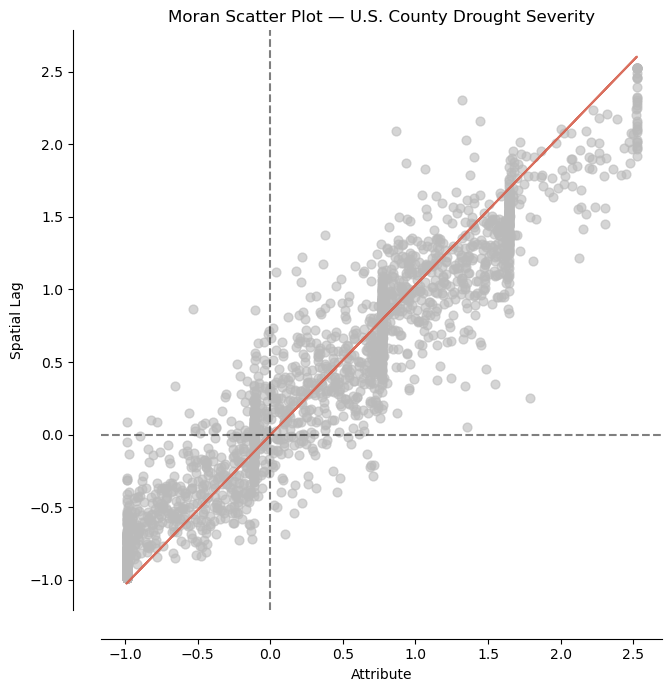

In [9]:
fig, ax = moran_scatterplot(moran)
plt.title("Moran Scatter Plot — U.S. County Drought Severity", fontsize=12)
plt.tight_layout()
plt.savefig("us_moran_scatterplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
lisa = Moran_Local(y, w)

counties_proj["lisa_cluster"] = lisa.q
counties_proj["lisa_pvalue"] = lisa.p_sim
counties_proj["significant"] = counties_proj["lisa_pvalue"] < 0.05

# Assign cluster types (significant only)
counties_proj["lisa_map"] = 0
counties_proj.loc[(counties_proj["significant"]) & 
                  (counties_proj["lisa_cluster"] == 1), "lisa_map"] = 1  # High-High
counties_proj.loc[(counties_proj["significant"]) & 
                  (counties_proj["lisa_cluster"] == 2), "lisa_map"] = 2  # Low-High
counties_proj.loc[(counties_proj["significant"]) & 
                  (counties_proj["lisa_cluster"] == 3), "lisa_map"] = 3  # Low-Low
counties_proj.loc[(counties_proj["significant"]) & 
                  (counties_proj["lisa_cluster"] == 4), "lisa_map"] = 4  # High-Low

# Count by cluster type
print(counties_proj["lisa_map"].value_counts().sort_index())

lisa_map
0    1078
1     844
2       2
3    1185
Name: count, dtype: int64


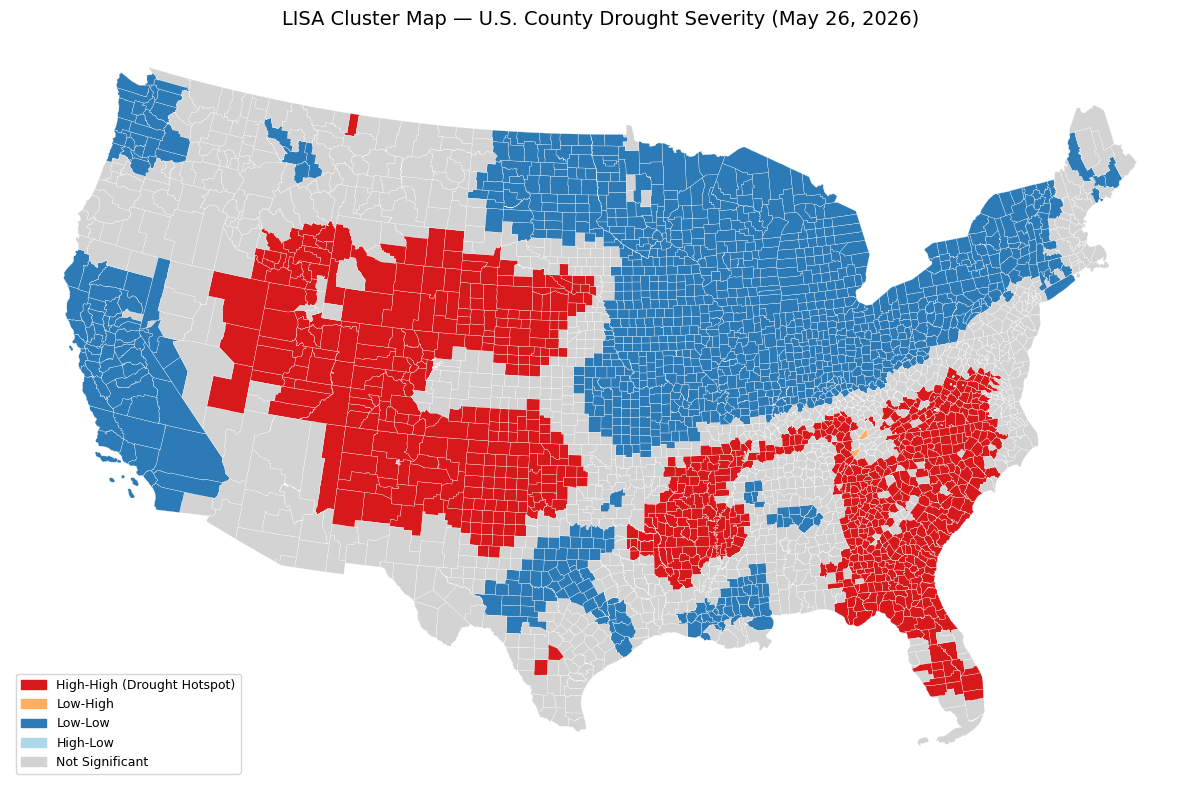

In [11]:
color_dict = {
    0: "#d3d3d3",  # Not significant
    1: "#d7191c",  # High-High
    2: "#fdae61",  # Low-High
    3: "#2c7bb6",  # Low-Low
    4: "#abd9e9",  # High-Low
}

counties_proj["color"] = counties_proj["lisa_map"].map(color_dict)

fig, ax = plt.subplots(figsize=(15, 8))
counties_proj.plot( color=counties_proj["color"],edgecolor="white",linewidth=0.2,ax=ax)

# Legend
patches = [
    mpatches.Patch(color="#d7191c", label="High-High (Drought Hotspot)"),
    mpatches.Patch(color="#fdae61", label="Low-High"),
    mpatches.Patch(color="#2c7bb6", label="Low-Low"),
    mpatches.Patch(color="#abd9e9", label="High-Low"),
    mpatches.Patch(color="#d3d3d3", label="Not Significant"),]
ax.legend(handles=patches, loc="lower left", fontsize=9)

plt.title("LISA Cluster Map — U.S. County Drought Severity (May 26, 2026)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig("us_lisa_cluster_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
counties_proj[["NAME", "STATEFP", "avg_drought_severity", 
               "percent_drought_area", "lisa_map"]].to_csv(
    "us_county_drought_results.csv", index=False)

print("Results saved.")

Results saved.


**Conclusion**

This analysis identified county-level drought hotspots across the contiguous United States 
using U.S. Drought Monitor data for May 26, 2026.

- The highest drought severity values were concentrated in **southern Georgia and 
  northern Florida**, with several counties reaching the maximum DM value of 4.0 
  (Exceptional Drought), including Brantley, Atkinson, and Charlton counties in Georgia
- Moran's I = **0.9123**, p = **0.001**, z-score = **87.89**, indicating 
  very strong and statistically significant positive spatial autocorrelation
- LISA cluster analysis identified **872 High-High counties** (drought hotspots) 
  concentrated in the West and southern Southeast, and **1,165 Low-Low counties** 
  in the northern Midwest and Northeast
- Drought conditions were not randomly distributed — they formed clear regional 
  clusters, with the western US and Southeast experiencing the most severe conditions

*Data sources: U.S. Drought Monitor, U.S. Census TIGER/Line 2025*

In [13]:
from bokeh.io import output_notebook, output_file, show
from bokeh.models import ColumnDataSource, ColorBar, HoverTool
from bokeh.plotting import figure
from bokeh.transform import linear_cmap
from bokeh.palettes import Viridis256
import numpy as np

output_notebook()

def gpd_bokeh(df):
    nan = float("nan")
    lons = []
    lats = []
    for shape in df.geometry.values:
        if shape.geom_type == "MultiPolygon":
            gx = []
            gy = []
            ng = len(shape.geoms) - 1
            for j, member in enumerate(shape.geoms):
                xy = np.array(list(member.exterior.coords))
                xs = xy[:, 0].tolist()
                ys = xy[:, 1].tolist()
                gx.extend(xs)
                gy.extend(ys)
                if j < ng:
                    gx.append(nan)
                    gy.append(nan)
            lons.append(gx)
            lats.append(gy)
        else:
            xy = np.array(list(shape.exterior.coords))
            xs = xy[:, 0].tolist()
            ys = xy[:, 1].tolist()
            lons.append(xs)
            lats.append(ys)
    return lons, lats

Loading BokehJS ...

In [14]:
lons, lats = gpd_bokeh(counties_proj)

source = ColumnDataSource(data=dict(
    x=lons,
    y=lats,
    county=counties_proj["NAME"],
    state=counties_proj["STATEFP"],
    avg_drought_severity=counties_proj["avg_drought_severity"].round(3),
    percent_drought_area=counties_proj["percent_drought_area"].round(2),
    lisa_cluster=counties_proj["lisa_map"] ))

In [ ]:
color_mapper = linear_cmap(field_name="avg_drought_severity", palette=Viridis256,
    low=counties_proj["avg_drought_severity"].min(),
    high=counties_proj["avg_drought_severity"].max())

TOOLS = "pan,wheel_zoom,reset,hover,save"

interactive_map = figure(width=900, height=550, title="Interactive Map of County-Level Average Drought Severity — May 26, 2026",tools=TOOLS)

interactive_map.patches("x", "y", source=source,line_color="white",line_width=0.5,color=color_mapper)

interactive_map.select_one(HoverTool).tooltips = [
    ("County",                  "@county"),
    ("State FIPS",              "@state"),
    ("Avg Drought Severity",    "@avg_drought_severity"),
    ("Percent Drought Area",    "@percent_drought_area %"),
    ("LISA Cluster",            "@lisa_cluster")]

color_bar = ColorBar( color_mapper=color_mapper["transform"], width=16,location=(0, 0),title="Avg. Drought Severity")

interactive_map.add_layout(color_bar, "right")
show(interactive_map)

In [ ]:
output_file("US_Drought_Hotspot_Analysis.html")
show(interactive_map)

## Conclusion

This analysis identified county-level drought hotspots across the contiguous United States 
using U.S. Drought Monitor data for May 26, 2026.

- The highest drought severity values were concentrated in **southern Georgia and 
  northern Florida**, with several counties reaching the maximum DM value of 4.0 
  (Exceptional Drought), including Brantley, Atkinson, and Charlton counties in Georgia
- Moran's I = **0.9123**, p = **0.001**, z-score = **87.89**, indicating 
  very strong and statistically significant positive spatial autocorrelation
- LISA cluster analysis identified **872 High-High counties** (drought hotspots) 
  concentrated in the West and southern Southeast, and **1,165 Low-Low counties** 
  in the northern Midwest and Northeast
- Drought conditions were not randomly distributed — they formed clear regional 
  clusters, with the western US and Southeast experiencing the most severe conditions

*Data sources: U.S. Drought Monitor, U.S. Census TIGER/Line 2025*